# Functions to parse and clean data

### Imports

In [6]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Parse data

In [ ]:
# PARSING 
def parse_custom_csv(path):
    with open(path, "r") as f:
        lines = f.readlines()

    sections = {"META": [], "EVENTS": [], "METER": []}
    current = None

    for line in lines:
        line = line.strip()

        if line.startswith("#"):
            current = line.replace("#", "").strip() #define current section as the header
            continue

        if current and line:  # <-- FIX: skip empty lines
            sections[current].append(line)

    # META
    meta = {}
    for row in sections["META"]:
        k, v = row.split(",", 1)
        meta[k] = v

   # EVENTS
    header = sections["EVENTS"][0].split(",")
    data = [r.split(",") for r in sections["EVENTS"][1:]]
    events = pd.DataFrame(data, columns=header)
    

    # METER
    clean_rows = []
    for line in sections["METER"]:
        parts = line.split(",")
        # Only keep valid rows with exactly 3 columns
        if len(parts) != 3:
            continue
        clean_rows.append(parts)
    meter = pd.DataFrame(clean_rows, columns=["timestamp", "v_shunt", "phase"])
    

    return meta, events, meter

## Clean data

In [4]:
# CLEANING
def clean_data(meta, meter, run_id):

    meter["timestamp"] = pd.to_datetime(meter["timestamp"])
    meter["v_shunt"] = meter["v_shunt"].astype(float)

    # Add run id
    meter["run"] = run_id

    # Add payload size
    meter["payload_size"] = 0
    # TX rows
    tx_mask = meter["phase"].astype(str).str.startswith("tx_")
    meter.loc[tx_mask, "payload_size"] = (
        meter.loc[tx_mask, "phase"]
        .str.replace("tx_", "")
        .astype(int)
    )
    return meta, meter

## Align timings and label phases
So that time is standard ofver all runs

In [ ]:
def align_time(meter):
    # Find first non-baseline timestamp
    non_baseline = meter[meter["phase"] != "baseline"]

    if len(non_baseline) == 0:
        raise ValueError("No non-baseline data found")

    t0 = non_baseline["timestamp"].iloc[0]

    # Create relative time
    meter["t_s"] = (meter["timestamp"] - t0).dt.total_seconds()

    return meter

In [26]:
# TIME ALIGNING
def align_time(events, meter):
    t0 = events["tx_start"].min()

    events["t_start_s"] = (events["tx_start"] - t0).dt.total_seconds()
    events["t_end_s"] = (events["rx_end"] - t0).dt.total_seconds()

    meter["t_s"] = (meter["timestamp"] - t0).dt.total_seconds()

    return events, meter

In [27]:
# LABELING PHASES
def label_phases(events, meter):
    meter["phase"] = "idle"
    meter["payload_size"] = 0

    for _, row in events.iterrows():
        mask = (
            (meter["t_s"] >= row["t_start_s"]) &
            (meter["t_s"] <= row["t_end_s"]) # make sure both start and end are in the transmission window
        )
        
        meter.loc[mask, "phase"] = "tx" # label phase as tx
        meter.loc[mask, "payload_size"] = int(row["payload_size"])

    return meter

## Test the functions

In [7]:
file1 = Path("/Users/jude/Documents/GitHub/BTR/experiment/WiFi/experiment 2 (byte-for-byte)/data/esp32/byte_by_byte/new best/esp32_byte_by_byte_run01.csv")
meta1, events1, meter1 = parse_custom_csv(file1)
meta1, meter1 = clean_data(meta1, meter1, run_id=1)
events1, meter1 = align_time(events1, meter1)
meter1 = label_phases(events1, meter1)
print(events1.head())
print(meter1.head())


/var/folders/y0/ntq2pbh53yb4nxf1rt5x3bxw0000gq/T/ipykernel_10250/3580037115.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  meter["timestamp"] = pd.to_datetime(meter["timestamp"])


DateParseError: Unknown datetime string format, unable to parse: timestamp, at position 0

Run on all files

In [ ]:
all_meter = []
all_events = []

data_dir = Path("/Users/jude/Documents/GitHub/BTR/experiment/data/esp32/full_payload")

for i, file in enumerate(sorted(data_dir.glob("*.csv"))):
    meta, events, meter = parse_custom_csv(file)
    meta, events, meter = clean_data(meta, events, meter, run_id=i)

    events, meter = align_time(events, meter)
    meter = label_phases(events, meter)

    all_meter.append(meter)
    all_events.append(events)

meter_df = pd.concat(all_meter, ignore_index=True)
events_df = pd.concat(all_events, ignore_index=True)

# Stats and plots 

AAAAAAAAAAAA STATS

Ok so i want

For **each seperate run**: mean power during transmissons, std (within run variation) and count, time spent in transmission state 
- tx 1 : avg v_shunt, std of v_shunt, count of measurements, Time 
- etc.

For **all runs**: Mean power of all ?byte transmission, std (between run variation) (count is 30), avg time spent in tx of payload, std and count ?


## Stats about voltage
nothing about power yet cause i dont know shunt resistance

In [ ]:
summary = (
    meter_df
    .groupby("payload_size")["v_shunt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
summary["sem"] = summary["std"] / np.sqrt(summary["count"])  # standard error
summary["ci95"] = 1.96 * summary["sem"]  # 95% confidence interval

print(summary)

    payload_size      mean       std  count       sem      ci95
0              0  0.106709  0.012536  31427  0.000071  0.000139
1              1  0.105872  0.010081   2079  0.000221  0.000433
2              2  0.108567  0.017586   5992  0.000227  0.000445
3              4  0.107042  0.011184   5836  0.000146  0.000287
4              8  0.107322  0.015903   6144  0.000203  0.000398
5             16  0.107171  0.011812   5836  0.000155  0.000303
6             32  0.107551  0.013212   5832  0.000173  0.000339
7             64  0.106596  0.011275   6086  0.000145  0.000283
8            128  0.108041  0.015495   5909  0.000202  0.000395
9            256  0.109236  0.017404   5962  0.000225  0.000442
10           512  0.106177  0.009782   6158  0.000125  0.000244
11          1024  0.106613  0.012277   6281  0.000155  0.000304
12          2048  0.108259  0.016010   6855  0.000193  0.000379
13          4096  0.106933  0.012133   7639  0.000139  0.000272
14          8192  0.107832  0.014293   9

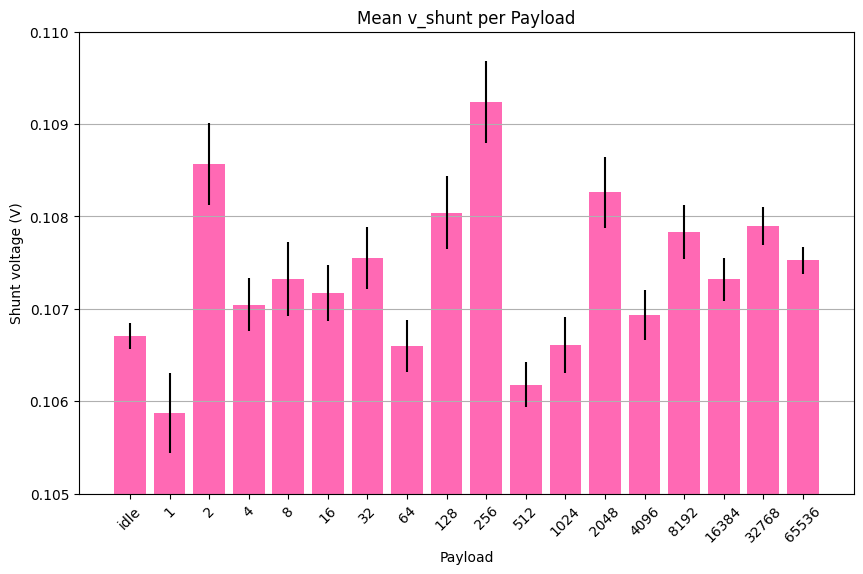

In [ ]:
summary["payload_label"] = summary["payload_size"].astype(str)
summary.loc[summary["payload_size"] == 0, "payload_label"] = "idle"

plt.figure(figsize=(10, 6))
plt.bar(
    summary["payload_label"],
    summary["mean"],
    yerr=summary["ci95"],
    color='hotpink',
)

#cut off y axis at 0.1
plt.ylim(0.105, 0.11)
plt.xlabel("Payload")
plt.ylabel("Shunt voltage (V)")
plt.title("Mean v_shunt per Payload")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

same thing but different, i kinda hate this

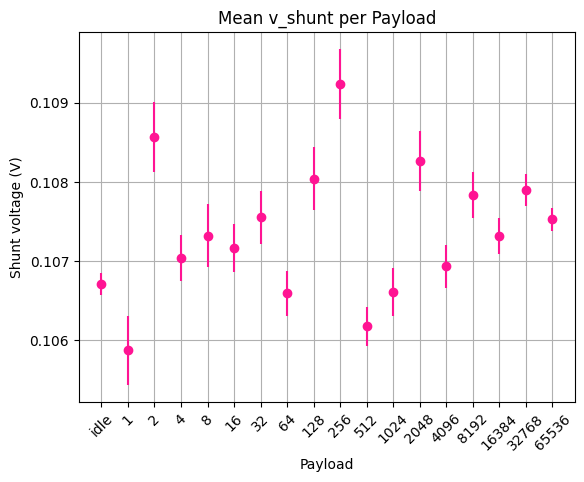

In [ ]:
plt.errorbar(
    summary["payload_label"],
    summary["mean"],
    yerr=summary["ci95"],
    fmt='o',
    color= 'deeppink'
)

plt.xlabel("Payload")
plt.ylabel("Shunt voltage (V)")
plt.title("Mean v_shunt per Payload")
plt.xticks(rotation=45)
plt.grid()
plt.show()

wanna see outliers and stuff

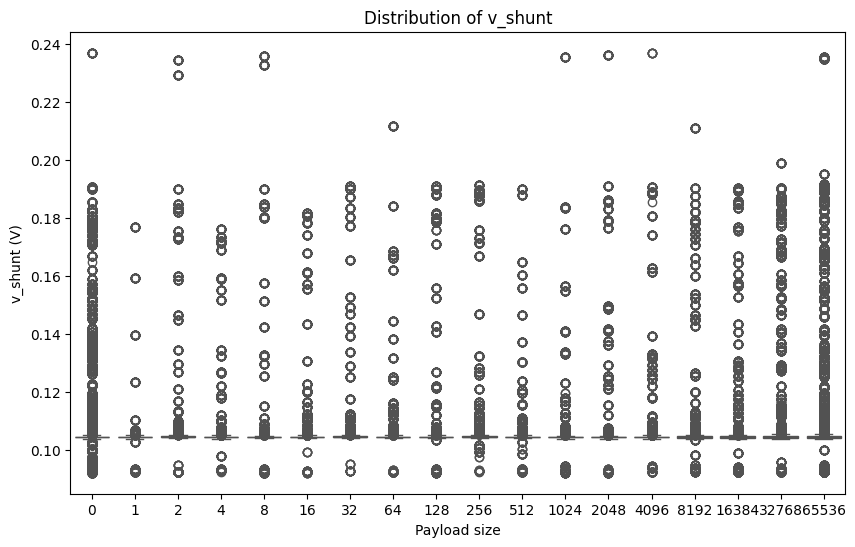

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=meter_df,
    x="payload_size",
    y="v_shunt",
    color='deeppink' #why is the color not changing?
)

plt.xlabel("Payload size")
plt.ylabel("v_shunt (V)")
plt.title("Distribution of v_shunt")
plt.show()

## Stats about time

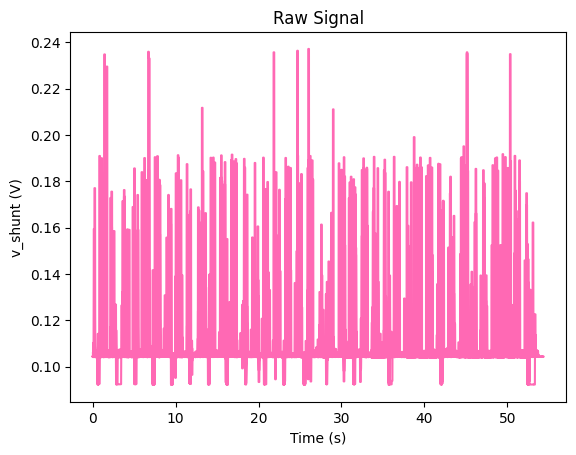

In [ ]:
plt.plot(meter_df["t_s"], meter_df["v_shunt"], color='hotpink')
plt.xlabel("Time (s)")
plt.ylabel("v_shunt (V)")
plt.title("Raw Signal")
plt.show()

In [ ]:
events_df["duration_s"] = (
    events_df["t_end_s"] - events_df["t_start_s"]
)

tx_summary = (
    events_df
    .groupby("payload_size")["duration_s"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
tx_summary["sem"] = tx_summary["std"] / np.sqrt(tx_summary["count"])  # standard error
tx_summary["ci95"] = 1.96 * tx_summary["sem"]  #95% confidence interval
print(tx_summary)

   payload_size       mean       std  count       sem      ci95
0             1   0.599062  0.067459     16  0.016865  0.033055
1          1024   1.811875  0.047165     16  0.011791  0.023111
2           128   1.716625  0.049628     16  0.012407  0.024318
3            16   1.687625  0.092863     16  0.023216  0.045503
4         16384   3.777188  0.130683     16  0.032671  0.064035
5             2   1.726562  0.173704     16  0.043426  0.085115
6          2048   1.974875  0.085262     16  0.021315  0.041778
7           256   1.714688  0.050624     16  0.012656  0.024806
8            32   1.695562  0.045910     16  0.011478  0.022496
9         32768   5.808125  0.101231     16  0.025308  0.049603
10            4   1.703875  0.163992     16  0.040998  0.080356
11         4096   2.194125  0.083696     16  0.020924  0.041011
12          512   1.796875  0.062177     16  0.015544  0.030467
13           64   1.758750  0.057245     16  0.014311  0.028050
14        65536  10.016875  0.230474    

In [ ]:
tx_summary["payload_size"] = tx_summary["payload_size"].astype(str)
#please order omg
plt.figure()
plt.bar(
    tx_summary["payload_size"].astype(str),
    tx_summary["mean"],
    yerr=tx_summary["ci95"],
    color='hotpink'
)
plt.loc = sorted(events_df["payload_size"].unique())
plt.xlabel("Payload size")
plt.ylabel("TX duration (s)")
plt.title("Transmission Time vs Payload Size")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

NameError: name 'tx_summary' is not defined